# CALIDAD DE DATOS

## IMPORTAR PAQUETES

In [99]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
import os
from pathlib import Path
import openpyxl
import sqlalchemy as sa

# Desactivar notación científica
pd.set_option('display.float_format', lambda x: '%.3f' % x)
np.set_printoptions(suppress=True)

# Cargar variables de entorno
load_dotenv()

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## IMPORTAR LOS DATOS

In [100]:
df = pd.read_pickle('../02_datos/03_Entrenamiento/train.pkl')
df

,id_cliente,empleo,antigüedad_empleo,ingresos,ingresos_verificados,rating,dti,vivienda,num_hipotecas,num_lineas_credito,...,id_prestamo,descripcion,finalidad,principal,tipo_interes,num_cuotas,imp_cuota,imp_amortizado,estado,imp_recuperado
2,46641215,Banker,5 years,135000.000,Verified,A,14.680,RENT,0.000,19.000,...,NaN,NaN,debt_consolidation,24000.000,6.390,36 months,734.380,24000.000,Fully Paid,0.000
4,132883631,Subsea Technician,7 years,125000.000,Source Verified,B,9.000,MORTGAGE,1.000,6.000,...,NaN,NaN,debt_consolidation,22000.000,10.900,36 months,719.220,22000.000,Fully Paid,0.000
5,131289518,NaN,10+ years,72777.000,Source Verified,D,24.740,MORTGAGE,2.000,10.000,...,NaN,NaN,home_improvement,25000.000,21.850,60 months,688.350,2811.270,Current,0.000
9,143175635,Registered Nurse,3 years,73000.000,Not Verified,A,5.520,RENT,0.000,6.000,...,NaN,NaN,debt_consolidation,7200.000,7.210,36 months,223.010,725.510,Current,0.000
10,44795538,firefighter,10+ years,98000.000,Verified,C,20.490,MORTGAGE,3.000,21.000,...,NaN,NaN,credit_card,21000.000,13.990,36 months,717.630,21000.000,Fully Paid,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199989,51896222,Technician,4 years,40000.000,Source Verified,B,23.310,RENT,0.000,7.000,...,NaN,NaN,credit_card,15000.000,11.530,36 months,494.860,15000.000,Fully Paid,0.000
199991,999338,T. Rowe Price,4 years,55000.000,Verified,B,29.260,RENT,NaN,7.000,...,NaN,Borrower added on 11/01/11 > Looking to use ...,debt_consolidation,20000.000,12.690,60 months,451.900,20000.000,Fully Paid,0.000
199996,121031962,Owner & President,6 years,111697.000,Verified,B,16.630,MORTGAGE,2.000,10.000,...,NaN,NaN,other,10000.000,9.440,36 months,320.050,4388.510,Current,0.000
199997,135641397,Sr. Field Engineer,10+ years,285000.000,Source Verified,D,6.020,MORTGAGE,3.000,9.000,...,NaN,NaN,small_business,30000.000,17.470,36 months,1076.620,5387.530,Current,0.000


In [101]:
# Eliminar el índice del DataFrame original creando uno nuevo autonumérico
df.reset_index(drop=True, inplace=True)

In [102]:
df

,id_cliente,empleo,antigüedad_empleo,ingresos,ingresos_verificados,rating,dti,vivienda,num_hipotecas,num_lineas_credito,...,id_prestamo,descripcion,finalidad,principal,tipo_interes,num_cuotas,imp_cuota,imp_amortizado,estado,imp_recuperado
0,46641215,Banker,5 years,135000.000,Verified,A,14.680,RENT,0.000,19.000,...,NaN,NaN,debt_consolidation,24000.000,6.390,36 months,734.380,24000.000,Fully Paid,0.000
1,132883631,Subsea Technician,7 years,125000.000,Source Verified,B,9.000,MORTGAGE,1.000,6.000,...,NaN,NaN,debt_consolidation,22000.000,10.900,36 months,719.220,22000.000,Fully Paid,0.000
2,131289518,NaN,10+ years,72777.000,Source Verified,D,24.740,MORTGAGE,2.000,10.000,...,NaN,NaN,home_improvement,25000.000,21.850,60 months,688.350,2811.270,Current,0.000
3,143175635,Registered Nurse,3 years,73000.000,Not Verified,A,5.520,RENT,0.000,6.000,...,NaN,NaN,debt_consolidation,7200.000,7.210,36 months,223.010,725.510,Current,0.000
4,44795538,firefighter,10+ years,98000.000,Verified,C,20.490,MORTGAGE,3.000,21.000,...,NaN,NaN,credit_card,21000.000,13.990,36 months,717.630,21000.000,Fully Paid,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,Technician,4 years,40000.000,Source Verified,B,23.310,RENT,0.000,7.000,...,NaN,NaN,credit_card,15000.000,11.530,36 months,494.860,15000.000,Fully Paid,0.000
139996,999338,T. Rowe Price,4 years,55000.000,Verified,B,29.260,RENT,NaN,7.000,...,NaN,Borrower added on 11/01/11 > Looking to use ...,debt_consolidation,20000.000,12.690,60 months,451.900,20000.000,Fully Paid,0.000
139997,121031962,Owner & President,6 years,111697.000,Verified,B,16.630,MORTGAGE,2.000,10.000,...,NaN,NaN,other,10000.000,9.440,36 months,320.050,4388.510,Current,0.000
139998,135641397,Sr. Field Engineer,10+ years,285000.000,Source Verified,D,6.020,MORTGAGE,3.000,9.000,...,NaN,NaN,small_business,30000.000,17.470,36 months,1076.620,5387.530,Current,0.000


## VISIÓN GENERAL

In [103]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 140000 entries, 0 to 139999
Data columns (total 25 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   140000 non-null  int64  
 1   empleo                       129671 non-null  str    
 2   antigüedad_empleo            130934 non-null  str    
 3   ingresos                     140000 non-null  float64
 4   ingresos_verificados         140000 non-null  str    
 5   rating                       140000 non-null  str    
 6   dti                          139898 non-null  float64
 7   vivienda                     140000 non-null  str    
 8   num_hipotecas                136883 non-null  float64
 9   num_lineas_credito           139998 non-null  float64
 10  porc_tarjetas_75p            135327 non-null  float64
 11  porc_uso_revolving           139889 non-null  float64
 12  num_cancelaciones_12meses    139990 non-null  float64
 13  num_deroga

## TIPOS DE DATOS

### Identificación

In [104]:
df.head().T

,0,1,2,3,4
id_cliente,46641215,132883631,131289518,143175635,44795538
empleo,Banker,Subsea Technician,NaN,Registered Nurse,firefighter
antigüedad_empleo,5 years,7 years,10+ years,3 years,10+ years
ingresos,135000.000,125000.000,72777.000,73000.000,98000.000
ingresos_verificados,Verified,Source Verified,Source Verified,Not Verified,Verified
rating,A,B,D,A,C
dti,14.680,9.000,24.740,5.520,20.490
vivienda,RENT,MORTGAGE,MORTGAGE,RENT,MORTGAGE
num_hipotecas,0.000,1.000,2.000,0.000,3.000
num_lineas_credito,19.000,6.000,10.000,6.000,21.000


In [105]:
df.dtypes

id_cliente                       int64
empleo                             str
antigüedad_empleo                  str
ingresos                       float64
ingresos_verificados               str
rating                             str
dti                            float64
vivienda                           str
num_hipotecas                  float64
num_lineas_credito             float64
porc_tarjetas_75p              float64
porc_uso_revolving             float64
num_cancelaciones_12meses      float64
num_derogatorios               float64
num_meses_desde_ult_retraso    float64
id_prestamo                    float64
descripcion                        str
finalidad                          str
principal                      float64
tipo_interes                   float64
num_cuotas                         str
imp_cuota                      float64
imp_amortizado                 float64
estado                             str
imp_recuperado                 float64
dtype: object

Conclusiones:
* dti= debt to income (varía entre 0 y 999). Vigilar
* num_hipotecas, num_lineas_credito, num_cancelaciones_12meses, num_derogatorios, num_meses_desde_ult_retraso deberían ser int
* pero vemos que hay nulos, así que no podemos convertirlas hasta que los imputemos

## VALORES ÚNICOS

### Identificación

In [106]:
df.nunique().sort_values()

id_prestamo                         0
num_cuotas                          2
ingresos_verificados                3
vivienda                            6
num_cancelaciones_12meses           7
rating                              7
estado                              9
antigüedad_empleo                  11
finalidad                          14
num_derogatorios                   18
num_hipotecas                      26
num_lineas_credito                 61
num_meses_desde_ult_retraso       130
porc_tarjetas_75p                 172
tipo_interes                      578
porc_uso_revolving               1099
principal                        1464
dti                              5275
descripcion                      7841
imp_recuperado                  10540
ingresos                        11682
imp_cuota                       33580
empleo                          54687
imp_amortizado                  57773
id_cliente                     140000
dtype: int64

Conclusiones:

* id_prestamo con menos de 2 valores --> eliminar

### Corrección

In [107]:
df.drop(columns = 'id_prestamo', inplace = True)

## DUPLICADOS

### Identificación

In [108]:
df.duplicated(subset='id_cliente').sum()

np.int64(0)

## SEPARAR NUMÉRICAS Y CATEGÓRICAS

### Categóricas

In [109]:
cat = df.select_dtypes(exclude = 'number').copy()

### Numéricas

In [110]:
num = df.select_dtypes(include='number').copy()

## GESTIÓN DE CATEGÓRICAS

### Nulos

#### Identificación

In [111]:
cat.isna().sum().sort_values(ascending = False)

descripcion             132135
empleo                   10329
antigüedad_empleo         9066
rating                       0
ingresos_verificados         0
vivienda                     0
finalidad                    0
num_cuotas                   0
estado                       0
dtype: int64

In [112]:
cat.descripcion.value_counts(dropna=False)

descripcion
NaN                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     132135
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            17
  Borrower added on 06/26/13 >

In [113]:
cat.empleo.value_counts(dropna=False)

empleo
NaN                                     10329
Teacher                                  2515
Manager                                  2145
Owner                                    1334
Registered Nurse                         1012
                                        ...  
Unified Strategies Group                    1
Charge Nurse of Emergency Department        1
TMS Domain Manager                          1
Owner & President                           1
Sr. Field Engineer                          1
Name: count, Length: 54688, dtype: int64

In [114]:
# Para intentar conseguir una variable que dijera "desempleado" he creado esta lista pero no vale la pena
no_employment_list =  [
    # Unemployed / Desempleado
    'unemployed', 'Unemployed',
    'jobless', 'Jobless',
    'out of work', 'Out of work',
    'out of a job', 'Out of a job',
    'no job', 'No job',
    'no employment', 'No employment',
    'without work', 'Without work',
    'between jobs', 'Between jobs',
    'laid off', 'Laid off',
    'redundant', 'Redundant',
    'furloughed', 'Furloughed',
    
    # Students / Estudiantes
    'student', 'Student',
    'studying', 'Studying',
    'full-time student', 'Full-time student',
    'full time student', 'Full time student',
    'part-time student', 'Part-time student',
    'college student', 'College student',
    'university student', 'University student',
    'scholar', 'Scholar',
    
    # Retired / Jubilados
    'retired', 'Retired',
    'retiree', 'Retiree',
    'pensioner', 'Pensioner',
    'on pension', 'On pension',
    
    # Homemakers / Cuidado del hogar y familia
    'homemaker', 'Homemaker',
    'housewife', 'Housewife',
    'househusband', 'Househusband',
    'stay-at-home mom', 'Stay-at-home mom',
    'stay at home mom', 'Stay at home mom',
    'stay-at-home dad', 'Stay-at-home dad',
    'stay at home dad', 'Stay at home dad',
    'stay-at-home parent', 'Stay-at-home parent',
    'stay at home parent', 'Stay at home parent',
    'family caregiver', 'Family caregiver',
    
    # Job Seekers / En búsqueda activa
    'job seeker', 'Job seeker',
    'jobseeker', 'Jobseeker',
    'looking for work', 'Looking for work',
    'looking for a job', 'Looking for a job',
    'seeking work', 'Seeking work',
    'seeking employment', 'Seeking employment',
    'searching for a job', 'Searching for a job',
    'open to work', 'Open to work',
    'open to opportunities', 'Open to opportunities',
    'available for work', 'Available for work',
    
    # Inactivity / Incapacidad o Inactividad
    'disabled', 'Disabled',
    'disability', 'Disability',
    'on disability', 'On disability',
    'unemployable', 'Unemployable',
    'not working', 'Not working',
    'none', 'None',
    'n/a', 'N/A',
    'na', 'NA'
]
cat.loc[cat.empleo.isin(no_employment_list)]


,empleo,antigüedad_empleo,ingresos_verificados,rating,vivienda,descripcion,finalidad,num_cuotas,estado
50690,retired,3 years,Not Verified,A,OWN,NaN,credit_card,60 months,Current
80173,Homemaker,10+ years,Not Verified,D,MORTGAGE,NaN,home_improvement,60 months,Charged Off
112159,Student,10+ years,Not Verified,A,MORTGAGE,NaN,debt_consolidation,36 months,Current
116804,Homemaker,< 1 year,Source Verified,C,MORTGAGE,NaN,credit_card,36 months,Fully Paid


In [115]:
cat.empleo.nunique()

54687

In [116]:
#La duda es si los que no tenemos dato de empleo es porque no lo sabemos o porque no tienen
cat.loc[cat.empleo.isna()]

,empleo,antigüedad_empleo,ingresos_verificados,rating,vivienda,descripcion,finalidad,num_cuotas,estado
2,NaN,10+ years,Source Verified,D,MORTGAGE,NaN,home_improvement,60 months,Current
6,NaN,NaN,Verified,C,RENT,NaN,debt_consolidation,36 months,Fully Paid
7,NaN,NaN,Verified,E,MORTGAGE,NaN,debt_consolidation,60 months,Fully Paid
14,NaN,< 1 year,Not Verified,A,MORTGAGE,NaN,credit_card,36 months,Current
16,NaN,NaN,Verified,C,RENT,Borrower added on 08/01/12 > it is for the c...,house,36 months,Charged Off
...,...,...,...,...,...,...,...,...,...
139899,NaN,NaN,Verified,D,RENT,NaN,other,36 months,Charged Off
139926,NaN,NaN,Source Verified,B,MORTGAGE,NaN,debt_consolidation,36 months,Fully Paid
139956,NaN,NaN,Not Verified,B,MORTGAGE,NaN,debt_consolidation,36 months,Fully Paid
139975,NaN,NaN,Verified,B,RENT,NaN,debt_consolidation,36 months,Fully Paid


In [117]:
cat.antigüedad_empleo.value_counts(dropna=False)

antigüedad_empleo
10+ years    46137
2 years      12572
< 1 year     11768
3 years      11225
1 year        9151
NaN           9066
5 years       8660
4 years       8502
6 years       6378
7 years       5850
8 years       5691
9 years       5000
Name: count, dtype: int64

Conclusiones:

* eliminar descripción y empleo
* imputar nulos de antigüedad_empleo por valor 'desconocido'

#### Corrección

In [118]:
# eliminar descripción y empleo
cat.drop(columns = ['descripcion', 'empleo'], inplace = True)

In [119]:
# imputar nulos de antigüedad_empleo por valor 'desconocido'
cat['antigüedad_empleo'] = cat['antigüedad_empleo'].fillna('desconocido')

In [120]:
cat.antigüedad_empleo.value_counts(dropna=False)

antigüedad_empleo
10+ years      46137
2 years        12572
< 1 year       11768
3 years        11225
1 year          9151
desconocido     9066
5 years         8660
4 years         8502
6 years         6378
7 years         5850
8 years         5691
9 years         5000
Name: count, dtype: int64

## GESTIÓN DE NUMÉRICAS

### Nulos

#### Identificación

In [121]:
num.isna().sum().sort_values(ascending = False)

num_meses_desde_ult_retraso    71799
porc_tarjetas_75p               4673
num_hipotecas                   3117
porc_uso_revolving               111
dti                              102
num_cancelaciones_12meses         10
num_lineas_credito                 2
num_derogatorios                   2
ingresos                           0
id_cliente                         0
principal                          0
tipo_interes                       0
imp_cuota                          0
imp_amortizado                     0
imp_recuperado                     0
dtype: int64

Veamoslas con más detalle.

In [122]:
num.num_meses_desde_ult_retraso.value_counts(dropna=False).sort_index()

num_meses_desde_ult_retraso
0.000        171
1.000        442
2.000        601
3.000        810
4.000        940
           ...  
151.000        1
159.000        1
180.000        1
195.000        1
NaN        71799
Name: count, Length: 131, dtype: int64

<Axes: ylabel='Frequency'>

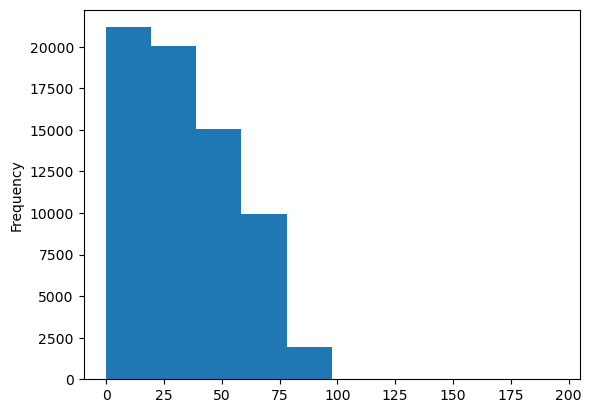

In [123]:
num.num_meses_desde_ult_retraso.plot(kind = 'hist')

Hay ceros, pero parecen pocos para una variable que implica retrasos.

Así que vamos a pensar que los nulos significan que no ha habido retrasos.

Y por tanto imputar por ceros.

In [124]:
num.porc_tarjetas_75p.value_counts(dropna=False).sort_index()

porc_tarjetas_75p
0.000      37020
0.250          2
0.400          1
0.500          3
0.570          1
           ...  
94.400         2
94.700         1
95.000         1
100.000    23190
NaN         4673
Name: count, Length: 173, dtype: int64

La categoría mayoritaria es cero.

Imputaremos por cero.

In [125]:
num.num_hipotecas.value_counts(dropna=False).sort_index()

num_hipotecas
0.000     57766
1.000     24508
2.000     20040
3.000     14306
4.000      9165
5.000      5347
6.000      2849
7.000      1459
8.000       697
9.000       341
10.000      197
11.000       84
12.000       34
13.000       28
14.000       21
15.000       14
16.000        5
17.000        4
18.000        6
19.000        3
20.000        2
21.000        2
23.000        2
25.000        1
27.000        1
32.000        1
NaN        3117
Name: count, dtype: int64

La categoría mayoritaria es cero.

Imputaremos por cero.

Conclusiones:

* imputar todas por ceros

#### Corrección

In [126]:
num.fillna(0,inplace=True)

,id_cliente,ingresos,dti,num_hipotecas,num_lineas_credito,porc_tarjetas_75p,porc_uso_revolving,num_cancelaciones_12meses,num_derogatorios,num_meses_desde_ult_retraso,principal,tipo_interes,imp_cuota,imp_amortizado,imp_recuperado
0,46641215,135000.000,14.680,0.000,19.000,0.000,16.300,0.000,0.000,0.000,24000.000,6.390,734.380,24000.000,0.000
1,132883631,125000.000,9.000,1.000,6.000,33.300,69.900,0.000,0.000,16.000,22000.000,10.900,719.220,22000.000,0.000
2,131289518,72777.000,24.740,2.000,10.000,33.300,63.200,0.000,0.000,0.000,25000.000,21.850,688.350,2811.270,0.000
3,143175635,73000.000,5.520,0.000,6.000,0.000,14.900,0.000,0.000,0.000,7200.000,7.210,223.010,725.510,0.000
4,44795538,98000.000,20.490,3.000,21.000,40.000,60.000,0.000,0.000,56.000,21000.000,13.990,717.630,21000.000,0.000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139995,51896222,40000.000,23.310,0.000,7.000,75.000,88.000,0.000,0.000,0.000,15000.000,11.530,494.860,15000.000,0.000
139996,999338,55000.000,29.260,0.000,7.000,0.000,66.400,0.000,0.000,0.000,20000.000,12.690,451.900,20000.000,0.000
139997,121031962,111697.000,16.630,2.000,10.000,50.000,26.300,0.000,1.000,6.000,10000.000,9.440,320.050,4388.510,0.000
139998,135641397,285000.000,6.020,3.000,9.000,25.000,21.100,0.000,0.000,25.000,30000.000,17.470,1076.620,5387.530,0.000


In [127]:
num.info()

<class 'pandas.DataFrame'>
RangeIndex: 140000 entries, 0 to 139999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   140000 non-null  int64  
 1   ingresos                     140000 non-null  float64
 2   dti                          140000 non-null  float64
 3   num_hipotecas                140000 non-null  float64
 4   num_lineas_credito           140000 non-null  float64
 5   porc_tarjetas_75p            140000 non-null  float64
 6   porc_uso_revolving           140000 non-null  float64
 7   num_cancelaciones_12meses    140000 non-null  float64
 8   num_derogatorios             140000 non-null  float64
 9   num_meses_desde_ult_retraso  140000 non-null  float64
 10  principal                    140000 non-null  float64
 11  tipo_interes                 140000 non-null  float64
 12  imp_cuota                    140000 non-null  float64
 13  imp_amorti

Una vez ya imputados los ceros podemos cambiar los tipos a int.

In [128]:
# meter num_hipotecas, num_lineas_credito, num_cancelaciones_12meses, num_derogatorios, num_meses_desde_ult_retraso en una lista y cambiar su tipo a entero
num_imputar_ceros = ['num_hipotecas', 'num_lineas_credito', 'num_cancelaciones_12meses', 'num_derogatorios', 'num_meses_desde_ult_retraso']
num[num_imputar_ceros] = num[num_imputar_ceros].astype(int)

In [129]:
num.info()

<class 'pandas.DataFrame'>
RangeIndex: 140000 entries, 0 to 139999
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id_cliente                   140000 non-null  int64  
 1   ingresos                     140000 non-null  float64
 2   dti                          140000 non-null  float64
 3   num_hipotecas                140000 non-null  int64  
 4   num_lineas_credito           140000 non-null  int64  
 5   porc_tarjetas_75p            140000 non-null  float64
 6   porc_uso_revolving           140000 non-null  float64
 7   num_cancelaciones_12meses    140000 non-null  int64  
 8   num_derogatorios             140000 non-null  int64  
 9   num_meses_desde_ult_retraso  140000 non-null  int64  
 10  principal                    140000 non-null  float64
 11  tipo_interes                 140000 non-null  float64
 12  imp_cuota                    140000 non-null  float64
 13  imp_amorti

### Atípicos

#### Por desviación típica

##### Identificación


Definir el número de desviaciones típicas

In [130]:
num_desv_tip = 4

Función que devuelve los índices de los atípicos

In [131]:
def atipicos_desv_tip(variable, num_desv_tip = 4):
    #sacamos los nulos por ahora
    variable = variable.dropna()
    #calculamos los límites
    media = np.mean(variable)
    sd = np.std(variable)
    umbral = sd * num_desv_tip
    lim_inf = media - umbral
    lim_sup = media + umbral
    #encontramos los índices de los que están fuera de los límites
    indices = [indice for indice,valor in variable.items() if valor < lim_inf or valor > lim_sup]
    return(indices)

Función que cuenta el número de atípicos

In [132]:
def conteo_atipicos(df,variable, num_desv_tip = 4):
    atipicos = atipicos_desv_tip(df[variable], num_desv_tip)
    return(df.loc[atipicos,variable].value_counts().sort_index())

Variables a aplicar

In [133]:
var_atipicos_dt = ['ingresos','principal','imp_cuota','imp_recuperado']

In [134]:
num.ingresos.describe()

count    140000.000
mean      78066.760
std       76860.312
min           0.000
25%       46000.000
50%       65000.000
75%       93000.000
max     9550000.000
Name: ingresos, dtype: float64

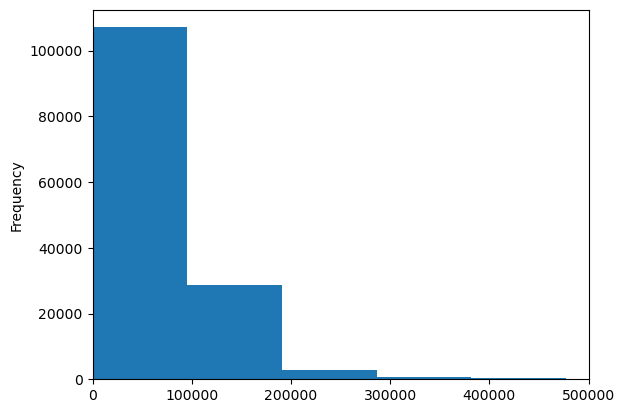

In [135]:
num.ingresos.plot(kind='hist', bins=100, xlim=(0, 500000));

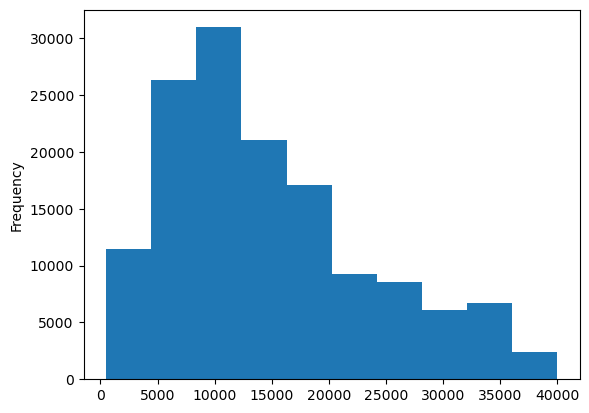

In [136]:
num.principal.plot(kind= 'hist');

Obtener los 10 primeros atipicos ordenados en cada variable

In [137]:
for variable in var_atipicos_dt:
    print('\n' + variable + ':\n')
    conteo = conteo_atipicos(num, variable, num_desv_tip)
    print(conteo.sort_index().head(10))


ingresos:

ingresos
386000.000    3
388000.000    1
389000.000    1
389500.000    1
390000.000    6
391000.000    1
393000.000    2
393230.000    1
395000.000    6
397000.000    1
Name: count, dtype: int64

principal:

Series([], Name: count, dtype: int64)

imp_cuota:

imp_cuota
1535.710    1
1566.800    1
1587.020    1
1714.540    1
Name: count, dtype: int64

imp_recuperado:

imp_recuperado
3236.120    1
3236.180    1
3238.150    1
3239.750    1
3240.900    1
3240.980    1
3241.680    1
3242.150    1
3242.410    1
3242.690    1
Name: count, dtype: int64


Revisamos con más detalle la variable ingresos.

In [139]:
num.ingresos.describe()

count    140000.000
mean      78066.760
std       76860.312
min           0.000
25%       46000.000
50%       65000.000
75%       93000.000
max     9550000.000
Name: ingresos, dtype: float64

##### Corrección

Eliminar los registros con ingresos superiores a 400.000$

*Cuidado: Si se eliminan registros hay que eliminarlos tanto de cat como de num*

In [140]:
# Guardas los índices molestos en un objeto Index de Pandas puro
a_eliminar = num.loc[num.ingresos > 400000].index

# Filtras usando .isin() directamente con ese Index
cat = cat[~cat.index.isin(a_eliminar)]
num = num[~num.index.isin(a_eliminar)]

###### Id de registros a eliminar

In [144]:
a_eliminar

Index([   290,    669,   1268,   1692,   1777,   1813,   2936,   3622,   4049,
         4140,
       ...
       135802, 136490, 136531, 137102, 137291, 137578, 137712, 139309, 139345,
       139644],
      dtype='int64', length=392)

###### Aplicar

In [142]:
cat = cat[~cat.index.isin(a_eliminar)]
num = num[~num.index.isin(a_eliminar)]

## GUARDAR DATASETS TRAS CALIDAD DE DATOS

Guarda los avances en df, cat y num con un sufijo para poder guardar o recuperar avances del proyecto.

En formato pickle para no perder las modificaciones de metadatos.

In [143]:
df.to_pickle('../02_datos/03_Entrenamiento/train_calidad.pkl')
cat.to_pickle('../02_datos/03_Entrenamiento/cat_calidad.pkl')
num.to_pickle('../02_datos/03_Entrenamiento/num_calidad.pkl')